In [1]:
import pandas as pd
import numpy as np
import requests
from pydantic import BaseModel, Field, field_validator


# ===== CONFIGURAÇÃO DO LOADER =====
class DataLoaderConfig(BaseModel):
    url: str = Field(..., description="URL do arquivo JSON")
    chave: str | None = Field(None, description="Chave do JSON a ser carregada")

    @field_validator("url")
    @classmethod
    def validar_url(cls, v: str) -> str:
        if not (v.startswith("http://") or v.startswith("https://")):
            raise ValueError("URL deve começar com http:// ou https://")
        return v

    model_config = {
        "extra": "allow",
        "json_schema_extra": {
            "example": {
                "url": "https://exemplo.com/dados.json",
                "chave": "dados_churn",
            }
        },
    }


# ===== FUNÇÃO DE CARREGAMENTO =====
def load_data(config: DataLoaderConfig) -> pd.DataFrame:
    """
    Carrega um JSON da URL e transforma em DataFrame.
    Se houver uma chave, extrai os dados dessa chave.
    """
    response = requests.get(config.url)
    response.raise_for_status()
    data = response.json()

    if isinstance(data, dict) and config.chave:
        data = data[config.chave]

    if isinstance(data, list):
        df = pd.json_normalize(data)
    elif isinstance(data, dict):
        df = pd.json_normalize([data])
    else:
        df = pd.DataFrame([data])

    return df


# ===== FUNÇÃO DE LIMPEZA =====
def clean_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Aplica regras específicas de limpeza:
    - Ajusta 'conta.cobranca.Total' quando vazio.
    - Ajusta 'cliente.tempo_servico'.
    - Remove linhas com 'Churn' vazio.
    """
    df = df.copy()

    # Substitui espaços em branco no total
    idx = df[df['conta.cobranca.Total'] == ' '].index
    df.loc[idx, "conta.cobranca.Total"] = df.loc[idx, "conta.cobranca.mensal"] * 24
    df.loc[idx, "cliente.tempo_servico"] = 24

    # Converte coluna para numérico
    df['conta.cobranca.Total'] = df['conta.cobranca.Total'].astype(float)

    # Remove churn vazio
    df = df[df['Churn'] != ''].copy()
    df.reset_index(drop=True, inplace=True)

    return df


# ===== FUNÇÃO DE TRATAMENTO DE NULOS =====
def handle_nulls(df: pd.DataFrame) -> pd.DataFrame:
    """
    Trata duplicadas e valores nulos:
    - Remove duplicadas.
    - Preenche tempo de serviço com base em Total/mensal.
    - Remove registros com nulos em colunas críticas.
    """
    df = df.copy()

    # Remove duplicadas
    df.drop_duplicates(inplace=True)

    # Preenche cliente.tempo_servico se for NaN
    filtro = df['cliente.tempo_servico'].isna()
    df.loc[filtro, 'cliente.tempo_servico'] = np.ceil(
        df.loc[filtro, 'conta.cobranca.Total'] / df.loc[filtro, 'conta.cobranca.mensal']
    )

    # Dropa linhas com nulos em colunas críticas
    colunas_dropar = [
        'conta.contrato',
        'conta.faturamente_eletronico',
        'conta.metodo_pagamento'
    ]
    df = df.dropna(subset=colunas_dropar).copy()
    df.reset_index(drop=True, inplace=True)

    return df


# ===== EXEMPLO DE USO =====
configs = {
    "churn": DataLoaderConfig(
        url="https://raw.githubusercontent.com/YuriArduino/Estudos_Pandas/refs/heads/data-tests/dataset-telecon.json",
        chave="dados_telecon"
    )
}

# Pipeline completo
df_raw = load_data(configs["churn"])
df_clean = clean_data(df_raw)
df_sem_nulo = handle_nulls(df_clean)

print("Shape final:", df_sem_nulo.shape)
df_sem_nulo.head()

Shape final: (7006, 21)


,id_cliente,Churn,cliente.genero,cliente.idoso,cliente.parceiro,cliente.dependentes,cliente.tempo_servico,telefone.servico_telefone,telefone.varias_linhas,internet.servico_internet,...,internet.backup_online,internet.protecao_dispositivo,internet.suporte_tecnico,internet.tv_streaming,internet.filmes_streaming,conta.contrato,conta.faturamente_eletronico,conta.metodo_pagamento,conta.cobranca.mensal,conta.cobranca.Total
0,0003-MKNFE,nao,masculino,0,nao,nao,9.0,sim,sim,DSL,...,nao,nao,nao,nao,sim,mes a mes,nao,cheque pelo correio,59.9,542.40
1,0004-TLHLJ,sim,masculino,0,nao,nao,4.0,sim,nao,fibra otica,...,nao,sim,nao,nao,nao,mes a mes,sim,cheque eletronico,73.9,280.85
2,0011-IGKFF,sim,masculino,1,sim,nao,13.0,sim,nao,fibra otica,...,sim,sim,nao,sim,sim,mes a mes,sim,cheque eletronico,98.0,1237.85
3,0013-EXCHZ,sim,feminino,1,sim,nao,3.0,sim,nao,fibra otica,...,nao,nao,sim,sim,nao,mes a mes,sim,cheque pelo correio,83.9,267.40
4,0013-MHZWF,nao,feminino,0,nao,sim,9.0,sim,nao,DSL,...,nao,nao,sim,sim,sim,mes a mes,sim,cartao de credito (automatico),69.4,571.45


#Outliers e como identificá-los



Já trabalhamos com **dados duplicados** e **dados nulos**, mas agora entra em cena um problema mais sutil: os **Outliers** — valores atípicos que se distanciam muito do padrão dos dados.

📊 Para identificá-los, uma das ferramentas mais utilizadas é o **boxplot (diagrama de caixa)**. Ele organiza os dados em quartis e evidencia pontos fora da curva.

* **Mediana (Q2):** divide o conjunto em duas metades (50% abaixo, 50% acima).
* **Q1 e Q3:** delimitam os 25% menores e maiores valores.
* **IIQ (Intervalo Interquartil):** diferença entre Q3 e Q1.
* **Limites inferior e superior:**

  * Inferior = Q1 − 1,5 × IIQ
  * Superior = Q3 + 1,5 × IIQ
* Valores fora desses limites são candidatos a **outliers**.

Antes do boxplot, usamos estatísticas descritivas (`.describe()`) para ter uma visão geral:

```python
df_sem_nulo.describe()
```

Esse método retorna **contagem, média, desvio padrão, valores mínimos, quartis (Q1, Q2, Q3)** e máximos.

👉 No nosso caso, um valor chama atenção:

* `cliente.tempo_servico` → máximo de **1080 meses** (90 anos).
  Um indício claro de outlier, já que não faz sentido um cliente ter contrato ativo por tanto tempo.

---

💡 **Dica rápida**

```python
import seaborn as sns
import matplotlib.pyplot as plt

# Boxplot da coluna tempo de serviço
sns.boxplot(x=df_sem_nulo["cliente.tempo_servico"])
plt.show()
```

Esse gráfico revela visualmente os **outliers** e facilita a análise.

---


In [2]:
df_sem_nulo.describe()

,cliente.idoso,cliente.tempo_servico,conta.cobranca.mensal,conta.cobranca.Total
count,7006.000000,7006.000000,7006.000000,7006.000000
mean,0.162004,33.286183,64.720361,2317.743862
std,0.368481,35.311206,30.084664,2876.919022
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.450000,402.087500
50%,0.000000,29.000000,70.300000,1392.925000
75%,0.000000,56.000000,89.850000,3783.600000
max,1.000000,1080.000000,118.750000,112212.000000


In [3]:
1080/12

90.0

In [4]:
import seaborn as sns

<Axes: xlabel='cliente.tempo_servico'>

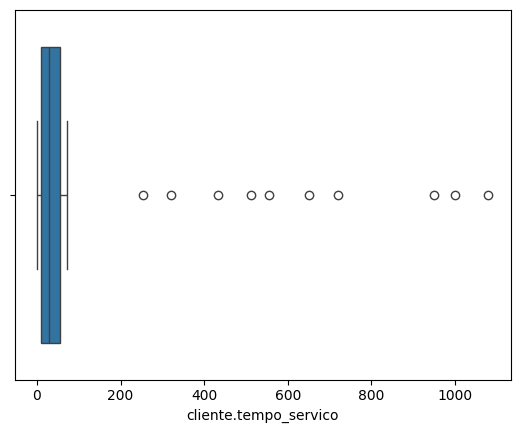

In [5]:
sns.boxplot(x=df_sem_nulo['cliente.tempo_servico'])

Notamos que a linha da mediana está por volta de 50. À direita temos vários pontos, sendo que de maior valor são por volta de 980, 1000 e 1100. Percebemos que esses são os candidatos a outliers.

Com isso, sabemos, de fato, que temos candidatos a outliers, mas não conseguimos identificar quais amostras são essas. Nossa intenção agora é identificá-los no nosso conjunto de dados. Para isso, na célula abaixo do diagrama, começaremos a fazer nossa seleção escrevendo:

`quantile()`

In [6]:
# Calcula o primeiro quartil (Q1) do tempo de serviço.
Q1 = df_sem_nulo['cliente.tempo_servico'].quantile(.25)
Q1

np.float64(9.0)

Assim, definimos que a variável Q1. Passamos o nosso DataFrame df_sem_nulo e delimitamos a coluna cliente.tempo_servico. Em seguida, usamos o método quantile(), passando o .25, para selecionarmos o primeiro quartil.

Na linha abaixo escrevemos o Q1 para termos como retorno o valor de Q1. Ao pressionarmos "Shift + Enter" para executar, recebemos "9.0" como resultado.

Na célula com o código anterior, apagaremos o Q1 da segunda linha. Depois copiaremos o código de declaração de Q1 e colaremos na linha abaixo, fazendo algumas mudanças. Mudaremos de Q1 para Q3, já que no diagrama de caixa temos o Q1 e o Q3. Além disso, mudaremos de (.25) para (.75), para obtermos os 75%, como mencionado anteriormente.

In [7]:
Q1 = df_sem_nulo['cliente.tempo_servico'].quantile(.25)
Q3 = df_sem_nulo['cliente.tempo_servico'].quantile(.75)

Ainda nessa célula, queremos o intervalo interquartil. Chamaremos essa variável de IQR, que é a forma que encontrarão nas literaturas, sendo que o "R" de "IQR" representa o range (amplitude/intervalo). Aprendemos a fórmula dele no boxplot, então, abaixo da declaração do Q3, codaremos IQR = Q3 - Q1.

Agora queremos os limites superior e inferior. Começaremos pelo limite inferior, escrevendo limite_inferior = Q1 - 1.5*IQR, sendo o IQR o intervalo interquartil definido anteriormente. Para o limite superior, podemos copiar o código anterior e fazer as mudanças necessárias, deixando como limite_superior = Q3 + 1.5*IQR.

In [8]:
Q1 = df_sem_nulo['cliente.tempo_servico'].quantile(.25)
Q3 = df_sem_nulo['cliente.tempo_servico'].quantile(.75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5*IQR
limite_superior = Q3 + 1.5*IQR

Temos nossas estatísticas com os exatos valores que observamos no modelo de boxplot anterior, apenas transformamos isso em código. Sendo assim, vamos pressionar "Shift + Enter" para executarmos nossa célula.

Após um rápido carregamento, nossa célula é executada. Agora faremos o filtro no nosso conjunto de dados a partir dessa medida. No nosso conjunto de dados, queremos valores que sejam menores que o limite inferior ou maiores que o limite superior.

Para isso, em uma nova célula escreveremos df_sem_nulo[], passando o nome da coluna dentro dos colchetes entre aspas simples, ou seja, 'cliente.tempo_servico. Escrevemos o sinal de menor que (<) e passamos o limite_inferior. Deixamos esse valor entre parênteses e usamos uma barra vertical (|) para representar o "ou".

Copiamos e colamos o código anterior depois da barra, mas mudamos o sinal de menor que pelo de maior que (>) e o limite_inferior pelo limite_superior. Em seguida, pressionamos "Shift + Enter" para executar o código.

In [9]:
(df_sem_nulo['cliente.tempo_servico'] < limite_inferior) | (df_sem_nulo['cliente.tempo_servico'] > limite_superior)

,cliente.tempo_servico
0,False
1,False
2,False
3,False
4,False
...,...
7001,False
7002,False
7003,False
7004,False


Percebemos que o retorno foi uma série de booleanos que podemos usar como filtro, pois são "true" (verdadeiro) ou "false" (falso). Sendo assim, vamos salvar esses dados em uma variável para usarmos como filtro.

Chamaremos essa variável de outliers_index, então, na célula anterior, onde escrevemos a fórmula, iremos igualar o código ao nome da variável. Em seguida, escreveremos o nome da variável na linha abaixo e executaremos o código novamente, para perceberem que é o mesmo retorno.

In [10]:
outliers_index = (df_sem_nulo['cliente.tempo_servico'] < limite_inferior) | (df_sem_nulo['cliente.tempo_servico'] > limite_superior)
outliers_index

,cliente.tempo_servico
0,False
1,False
2,False
3,False
4,False
...,...
7001,False
7002,False
7003,False
7004,False


Nossa intenção agora é saber quais são essas amostras. Para isso, passaremos esse filtro que acabamos de criar para o banco de dados. Se codarmos apenas df_sem_nulo[outliers_index], aparecerá todas as colunas do nosso DataFrame, mas contendo apenas as amostras que são outliers.

Porém, não queremos toda tabela, e sim os dados da coluna cliente.tempo_servico. Portanto, escreveremos df_sem_nulo[outliers_index]['cliente.tempo_servico'] e executaremos o código.

In [11]:
df_sem_nulo[outliers_index]['cliente.tempo_servico'].sort_values(ascending=False)

,cliente.tempo_servico
1945,1080.0
1946,1000.0
1952,950.0
1966,721.0
1963,650.0
1970,555.0
1974,512.0
1973,433.0
1958,321.0
1956,254.0


##Substituindo valores para os outliers

In [12]:
df_sem_out = df_sem_nulo.copy()

Com esse código, estamos criando o DataFrame df_sem_out, para os dados sem outliers, a partir de uma cópia do df_sem_nulo. Dessa forma podemos fazer alterações no novo DataFrame, sem fazemos mudar o df_sem_nulo que está funcionando.

Vamos pressionar "Shift + Enter" e esperar a execução da célula. Em seguida, podemos fazer a busca pelo df_sem_out para confirmar que se trata dos mesmos dados. Usaremos um código parecido com o do vídeo passado, mas dessa vez para buscar o df_sem_out:

In [13]:
df_sem_out [outliers_index]['cliente.tempo_servico']

,cliente.tempo_servico
1945,1080.0
1946,1000.0
1952,950.0
1956,254.0
1958,321.0
1963,650.0
1966,721.0
1970,555.0
1973,433.0
1974,512.0


`np.ceil`
`.loc[]`

In [14]:
#Arredondar resultado
#Percorrer as amostras
df_sem_out.loc[outliers_index, 'cliente.tempo_servico'] = np.ceil(
    df_sem_out.loc[outliers_index, 'conta.cobranca.Total'] /
    df_sem_out.loc[outliers_index, 'conta.cobranca.mensal']
)

<Axes: xlabel='cliente.tempo_servico'>

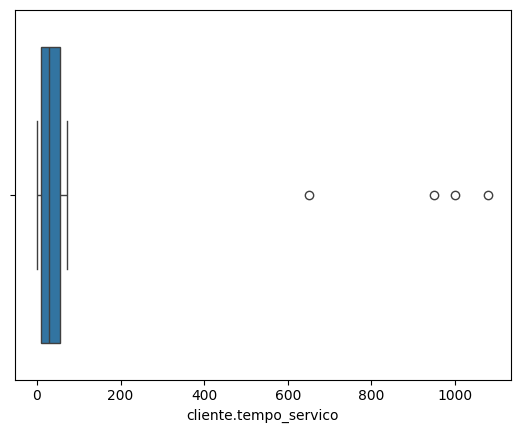

In [15]:
sns.boxplot(x=df_sem_out['cliente.tempo_servico'])

Percebemos que alguns valores foram substituídos, e encontramos: 2, 43, 44, 7, 4 e 1. Contudo, alguns valores sobraram, sendo eles: 1080, 1000, 951 e 650. Lembrando que anteriormente, o valor do "1952" era "950.0", mas como fizemos a divisão e arredondamos para cima, a casa decimal fez o valor aumentar para "951.0".

Então temos quatro valores que continuam sendo outliers, e podemos analisar porque isso aconteceu. Para isso, envolveremos a ['cliente.tempo_servico'] em colchetes para criarmos uma lista de colunas.

Nessa lista, passaremos as outras duas colunas relacionadas: a conta.cobranca.mensal e a conta.cobranca.Total. Sendo assim, temos [['cliente.tempo_servico', 'conta.cobranca.mensal', 'conta.cobranca.Total']]. Feita essa mudança, executaremos o código.

In [16]:
df_sem_out [outliers_index][['cliente.tempo_servico', 'conta.cobranca.mensal', 'conta.cobranca.Total']]

,cliente.tempo_servico,conta.cobranca.mensal,conta.cobranca.Total
1945,1080.0,103.90,112212.00
1946,1000.0,45.90,45900.00
1952,951.0,84.10,79895.00
1956,2.0,46.05,80.35
1958,43.0,99.80,4259.30
1963,650.0,73.00,47450.00
1966,44.0,89.55,3856.75
1970,7.0,19.15,124.40
1973,4.0,89.20,346.20
1974,1.0,19.55,19.55


Percebemos que algumas amostras ainda são outliers porque o valor em "conta.cobranca.Total" também é outlier. Quando realizamos a divisão de um outlier por um valor normal, continua sendo outlier.

Sendo assim, não temos como inferir com propriedade o valor de cliente.tempo_servico nessas amostras que continuam sendo outliers. Nesse caso, o que podemos fazer é retirar essas amostras.

---

### Para saber mais: formas de identificar outliers

Próxima Atividade

Existem várias técnicas para detectar **outliers** em conjuntos de dados. As mais comuns são: **Z-score**, **Regra dos 3 sigmas** e **Análise de dispersão**.

---

#### 1) Z-score

O **z-score** mede quantos desvios-padrão um valor está distante da média. Valores acima de `|3|` costumam ser considerados outliers.

```python
import numpy as np

data = np.array([10, 20, 30, 40, 150, 50, 60, 70, 80, 90, 100, 350])
z_scores = (data - np.mean(data)) / np.std(data)

outliers = data[np.abs(z_scores) > 3]
print("Outliers encontrados:", outliers)
```

👉 Útil em distribuições aproximadamente **normais**.

---

#### 2) Regra dos 3 sigmas

Baseada na distribuição normal: **99,7% dos valores** ficam dentro de 3 desvios-padrão. O que estiver além disso é candidato a outlier.

```python
import numpy as np

dados = np.array([0, 10, 12, 13, 15, 16, 18, 20, 22, 25, 30, 35, 40, 50, 350])
media, desvio = np.mean(dados), np.std(dados)

lim_sup = media + (3 * desvio)
lim_inf = media - (3 * desvio)

outliers = dados[(dados > lim_sup) | (dados < lim_inf)]
print("Outliers:", outliers)
```

👉 Bom para dados **simétricos e contínuos**.

---

#### 3) Análise de dispersão (Boxplot)

O **boxplot** mostra quartis e destaca pontos fora do intervalo interquartílico (Q1 − 1,5×IIQ, Q3 + 1,5×IIQ).

```python
import matplotlib.pyplot as plt
import numpy as np

data = np.array([10, 20, 30, 40, 50, 60, 70, 80, 90, 100])

plt.boxplot(data)
plt.show()

outliers = data[(data < np.percentile(data, 25) - 1.5 * (np.percentile(data, 75) - np.percentile(data, 25))) |
                (data > np.percentile(data, 75) + 1.5 * (np.percentile(data, 75) - np.percentile(data, 25)))]
print("Outliers encontrados:", outliers)
```

👉 Fácil de **visualizar e interpretar**, mesmo em dados assimétricos.

---

🔑 **Resumo rápido:**

* **Z-score / 3 sigmas** → bons em dados normais.
* **Boxplot** → flexível, ótimo para detectar discrepâncias em dados reais.

---


A primeira coisa que prestaremos atenção é que o outliers_index está comprometido. Se fizermos um filtro, como na aula passada, temos o retorno de valores que são outliers, mas também de valores que não são outliers.

In [17]:
df_sem_out [outliers_index]['cliente.tempo_servico'].sort_values(ascending=False)

,cliente.tempo_servico
1945,1080.0
1946,1000.0
1952,951.0
1963,650.0
1966,44.0
1958,43.0
1970,7.0
1973,4.0
1956,2.0
1974,1.0


Notamos que o retorno tem valores que são outliers: 1080, 1000, 951 e 650. Entretanto, temos também valores que não são mais outliers: 2, 43, 44, 7, 4 e 1. Sendo assim, precisamos refazer esse filtro, porque ele já está comprometido. Faremos isso copiando os códigos em que fizemos essa seleção e colando em uma nova célula.


>No Google Colab, Ctrl+Shift+L é um atalho para adicionar um cursor a cada ocorrência do texto selecionado no momento, permitindo a edição de várias linhas

In [18]:
# Recalcula os quartis, IQR e limites com base no DataFrame df_sem_out atualizado

Q1 = df_sem_out['cliente.tempo_servico'].quantile(.25)
Q3 = df_sem_out['cliente.tempo_servico'].quantile(.75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5*IQR
limite_superior = Q3 + 1.5*IQR

outliers_index = (df_sem_out['cliente.tempo_servico'] < limite_inferior) | (df_sem_out['cliente.tempo_servico'] > limite_superior)
outliers_index

,cliente.tempo_servico
0,False
1,False
2,False
3,False
4,False
...,...
7001,False
7002,False
7003,False
7004,False


In [19]:
df_sem_out[outliers_index]

,id_cliente,Churn,cliente.genero,cliente.idoso,cliente.parceiro,cliente.dependentes,cliente.tempo_servico,telefone.servico_telefone,telefone.varias_linhas,internet.servico_internet,...,internet.backup_online,internet.protecao_dispositivo,internet.suporte_tecnico,internet.tv_streaming,internet.filmes_streaming,conta.contrato,conta.faturamente_eletronico,conta.metodo_pagamento,conta.cobranca.mensal,conta.cobranca.Total
1945,2830-LEWOA,nao,masculino,0,sim,sim,1080.0,sim,nao,fibra otica,...,sim,sim,sim,sim,sim,um ano,nao,cartao de credito (automatico),103.9,112212.0
1946,2831-EBWRN,nao,masculino,0,nao,nao,1000.0,sim,nao,DSL,...,nao,nao,nao,nao,nao,mes a mes,sim,cheque eletronico,45.9,45900.0
1952,2834-SPCJV,sim,masculino,0,sim,nao,951.0,sim,nao,fibra otica,...,nao,nao,nao,sim,nao,mes a mes,nao,cheque eletronico,84.1,79895.0
1963,2851-STERV,nao,masculino,1,nao,nao,650.0,sim,nao,DSL,...,nao,sim,sim,sim,sim,um ano,sim,cheque eletronico,73.0,47450.0


Entretanto, o que queremos é um dataframe com todos os dados, exceto os que obtemos. Sendo assim, antes de outliers_index, escreveremos o til (~), que é o sinal de negação. Dessa forma, obteremos atribuiremos ao df_sem_out todas as amostras, menos as com outliers, tal como queremos. Por fim, podemos chamar o df_sem_out e executar o código.

`(~)`

In [20]:
df_sem_out = df_sem_out[~outliers_index]
df_sem_out

,id_cliente,Churn,cliente.genero,cliente.idoso,cliente.parceiro,cliente.dependentes,cliente.tempo_servico,telefone.servico_telefone,telefone.varias_linhas,internet.servico_internet,...,internet.backup_online,internet.protecao_dispositivo,internet.suporte_tecnico,internet.tv_streaming,internet.filmes_streaming,conta.contrato,conta.faturamente_eletronico,conta.metodo_pagamento,conta.cobranca.mensal,conta.cobranca.Total
0,0003-MKNFE,nao,masculino,0,nao,nao,9.0,sim,sim,DSL,...,nao,nao,nao,nao,sim,mes a mes,nao,cheque pelo correio,59.90,542.40
1,0004-TLHLJ,sim,masculino,0,nao,nao,4.0,sim,nao,fibra otica,...,nao,sim,nao,nao,nao,mes a mes,sim,cheque eletronico,73.90,280.85
2,0011-IGKFF,sim,masculino,1,sim,nao,13.0,sim,nao,fibra otica,...,sim,sim,nao,sim,sim,mes a mes,sim,cheque eletronico,98.00,1237.85
3,0013-EXCHZ,sim,feminino,1,sim,nao,3.0,sim,nao,fibra otica,...,nao,nao,sim,sim,nao,mes a mes,sim,cheque pelo correio,83.90,267.40
4,0013-MHZWF,nao,feminino,0,nao,sim,9.0,sim,nao,DSL,...,nao,nao,sim,sim,sim,mes a mes,sim,cartao de credito (automatico),69.40,571.45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7001,9987-LUTYD,nao,feminino,0,nao,nao,13.0,sim,nao,DSL,...,nao,nao,sim,nao,nao,um ano,nao,cheque pelo correio,55.15,742.90
7002,9992-RRAMN,sim,masculino,0,sim,nao,22.0,sim,sim,fibra otica,...,nao,nao,nao,nao,sim,mes a mes,sim,cheque eletronico,85.10,1873.70
7003,9992-UJOEL,nao,masculino,0,nao,nao,2.0,sim,nao,DSL,...,sim,nao,nao,nao,nao,mes a mes,sim,cheque pelo correio,50.30,92.75
7004,9993-LHIEB,nao,masculino,0,sim,sim,67.0,sim,nao,DSL,...,nao,sim,sim,nao,sim,dois anos,nao,cheque pelo correio,67.85,4627.65


Com isso, recebemos o retorno do dataframe e percebemos que o index das amostras vai até o 7005, mas só temos apenas 7002 amostras no nosso conjunto de dados. Portanto, as quatro amostras anteriores foram retiradas como nós queríamos.

Podemos conferir agora se não há mais candidatos outliers presentes no nosso conjunto de dados. Para isso, podemos criar outro boxplot em uma nova célula, executando o código sns.boxplot(x=df_sem_out['cliente.tempo_servico']).

<Axes: xlabel='cliente.tempo_servico'>

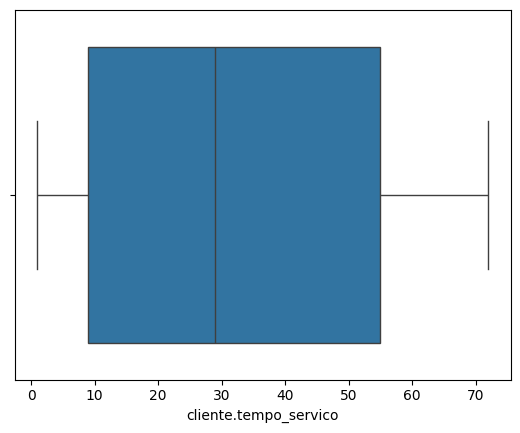

In [21]:
sns.boxplot(x=df_sem_out['cliente.tempo_servico'])

In [22]:
df_sem_out.reset_index(drop=True, inplace=True)
df_sem_out

,id_cliente,Churn,cliente.genero,cliente.idoso,cliente.parceiro,cliente.dependentes,cliente.tempo_servico,telefone.servico_telefone,telefone.varias_linhas,internet.servico_internet,...,internet.backup_online,internet.protecao_dispositivo,internet.suporte_tecnico,internet.tv_streaming,internet.filmes_streaming,conta.contrato,conta.faturamente_eletronico,conta.metodo_pagamento,conta.cobranca.mensal,conta.cobranca.Total
0,0003-MKNFE,nao,masculino,0,nao,nao,9.0,sim,sim,DSL,...,nao,nao,nao,nao,sim,mes a mes,nao,cheque pelo correio,59.90,542.40
1,0004-TLHLJ,sim,masculino,0,nao,nao,4.0,sim,nao,fibra otica,...,nao,sim,nao,nao,nao,mes a mes,sim,cheque eletronico,73.90,280.85
2,0011-IGKFF,sim,masculino,1,sim,nao,13.0,sim,nao,fibra otica,...,sim,sim,nao,sim,sim,mes a mes,sim,cheque eletronico,98.00,1237.85
3,0013-EXCHZ,sim,feminino,1,sim,nao,3.0,sim,nao,fibra otica,...,nao,nao,sim,sim,nao,mes a mes,sim,cheque pelo correio,83.90,267.40
4,0013-MHZWF,nao,feminino,0,nao,sim,9.0,sim,nao,DSL,...,nao,nao,sim,sim,sim,mes a mes,sim,cartao de credito (automatico),69.40,571.45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6997,9987-LUTYD,nao,feminino,0,nao,nao,13.0,sim,nao,DSL,...,nao,nao,sim,nao,nao,um ano,nao,cheque pelo correio,55.15,742.90
6998,9992-RRAMN,sim,masculino,0,sim,nao,22.0,sim,sim,fibra otica,...,nao,nao,nao,nao,sim,mes a mes,sim,cheque eletronico,85.10,1873.70
6999,9992-UJOEL,nao,masculino,0,nao,nao,2.0,sim,nao,DSL,...,sim,nao,nao,nao,nao,mes a mes,sim,cheque pelo correio,50.30,92.75
7000,9993-LHIEB,nao,masculino,0,sim,sim,67.0,sim,nao,DSL,...,nao,sim,sim,nao,sim,dois anos,nao,cheque pelo correio,67.85,4627.65


# Exercício: identificando fraudes


Você trabalha em um banco como cientista de dados e recebeu o seguinte conjunto de dados para analisar:

````

import pandas as pd

# criando um DataFrame com 30 transações aleatórias
df = pd.DataFrame({
    'ID da transação': range(1, 31),
    'Valor da transação': [100, 200, 150, 500, 300, 913, 250, 400, 200, 150,
                           200, 200, 400, 300, 150, 301, 805, 300, 400, 250,
                           150, 100, 500, 600, 200, 350, 100, 250, 800, 250],
    'Data da transação': pd.date_range(start='2022-01-01', end='2022-01-30', freq='D'),
    'Local da transação': ['São Paulo, Brasil', 'Rio de Janeiro, Brasil', 'Belo Horizonte, Brasil', 'São Paulo, Brasil',
                           'São Paulo, Brasil', 'Nova Iorque, EUA', 'São Paulo, Brasil', 'São Paulo, Brasil', 'São Paulo, Brasil',
                           'Rio de Janeiro, Brasil', 'São Paulo, Brasil', 'São Paulo, Brasil', 'São Paulo, Brasil', 'São Paulo, Brasil',
                           'São Paulo, Brasil', 'São Paulo, Brasil', 'Los Angeles, EUA', 'São Paulo, Brasil', 'São Paulo, Brasil', 'São Paulo, Brasil',
                           'São Paulo, Brasil', 'São Paulo, Brasil', 'São Paulo, Brasil', 'São Paulo, Brasil', 'São Paulo, Brasil', 'São Paulo, Brasil',
                           'São Paulo, Brasil', 'São Paulo, Brasil', 'Miami, EUA', 'São Paulo, Brasil']


````
Foi informado que nessa base de dados há possíveis fraudes que podem ser identificadas através dos outliers no “valor da transação”. Basicamente a fraude seria um outlier.

Sua missão é construir uma função que recebe dois parâmetros, a coluna que você quer analisar se tem outlier e o DataFrame em questão. A intenção de fazer isso é aproveitar novamente essa função tanto para outras colunas quanto para outros DataFrames futuramente em outras análises. O método que deve ser implementado para identificação do outlier é do intervalo interquartil.

Como podemos fazer isso?

In [47]:
import pandas as pd

# criando um DataFrame com 30 transações aleatórias
data = pd.DataFrame({
    'ID da transação': range(1, 31),
    'Valor da transação': [100, 200, 150, 500, 300, 913, 250, 400, 200, 150,
                           200, 200, 400, 300, 150, 301, 805, 300, 400, 250,
                           150, 100, 500, 600, 200, 350, 100, 250, 800, 250],
    'Data da transação': pd.date_range(start='2022-01-01', end='2022-01-30', freq='D'),
    'Local da transação': ['São Paulo, Brasil', 'Rio de Janeiro, Brasil', 'Belo Horizonte, Brasil', 'São Paulo, Brasil',
                           'São Paulo, Brasil', 'Nova Iorque, EUA', 'São Paulo, Brasil', 'São Paulo, Brasil', 'São Paulo, Brasil',
                           'Rio de Janeiro, Brasil', 'São Paulo, Brasil', 'São Paulo, Brasil', 'São Paulo, Brasil', 'São Paulo, Brasil',
                           'São Paulo, Brasil', 'São Paulo, Brasil', 'Los Angeles, EUA', 'São Paulo, Brasil', 'São Paulo, Brasil', 'São Paulo, Brasil',
                           'São Paulo, Brasil', 'São Paulo, Brasil', 'São Paulo, Brasil', 'São Paulo, Brasil', 'São Paulo, Brasil', 'São Paulo, Brasil',
                           'São Paulo, Brasil', 'São Paulo, Brasil', 'Miami, EUA', 'São Paulo, Brasil']
})


data.head()

,ID da transação,Valor da transação,Data da transação,Local da transação
0,1,100,2022-01-01,"São Paulo, Brasil"
1,2,200,2022-01-02,"Rio de Janeiro, Brasil"
2,3,150,2022-01-03,"Belo Horizonte, Brasil"
3,4,500,2022-01-04,"São Paulo, Brasil"
4,5,300,2022-01-05,"São Paulo, Brasil"


In [48]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   ID da transação     30 non-null     int64         
 1   Valor da transação  30 non-null     int64         
 2   Data da transação   30 non-null     datetime64[ns]
 3   Local da transação  30 non-null     object        
dtypes: datetime64[ns](1), int64(2), object(1)
memory usage: 1.1+ KB


In [49]:
data.describe()

,ID da transação,Valor da transação,Data da transação
count,30.000000,30.000000,30
mean,15.500000,325.633333,2022-01-15 12:00:00
min,1.000000,100.000000,2022-01-01 00:00:00
25%,8.250000,200.000000,2022-01-08 06:00:00
50%,15.500000,250.000000,2022-01-15 12:00:00
75%,22.750000,400.000000,2022-01-22 18:00:00
max,30.000000,913.000000,2022-01-30 00:00:00
std,8.803408,214.442579,NaN


🔎 Detectadas 2 possíveis fraudes (outliers) na coluna 'Valor da transação'.
🆔 IDs suspeitos: [6, 17]
📊 DataFrame original: 30 linhas | Após limpeza: 28 linhas


<Axes: xlabel='Valor da transação', ylabel='Count'>

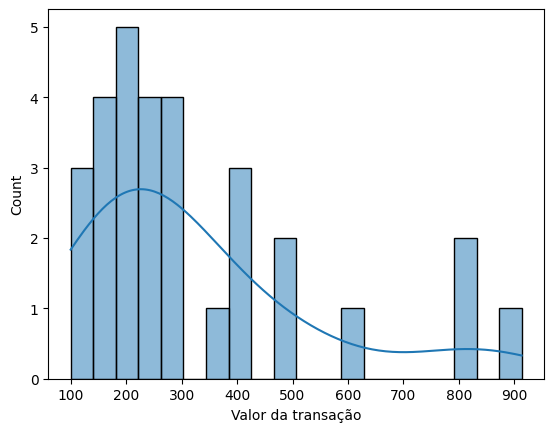

In [87]:
import pandas as pd

def treat_outliers_iqr(df: pd.DataFrame, column: str, id_col: str = "ID da transação"):
    """
    Identifica e remove outliers de uma coluna numérica usando o método do IQR.

    Args:
        df (pd.DataFrame): DataFrame a ser tratado
        column (str): Nome da coluna numérica a ser analisada
        id_col (str): Nome da coluna que contém os IDs (default: 'ID da transação')

    Returns:
        tuple: (df_sem_outliers, df_outliers)
    """
    df = df.copy()

    # Calcular Q1, Q3 e IQR
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    k = 2.0
    # k = 1.5 → detecção de outliers moderados (mais usado em análises exploratórias).
    # k = 3.0 → detecção de outliers extremos (pontos realmente fora da curva).
    limite_inferior = Q1 - k * IQR
    limite_superior = Q3 + k * IQR

    # Identificar outliers
    outliers_mask = (df[column] < limite_inferior) | (df[column] > limite_superior)
    df_outliers = df.loc[outliers_mask].copy()
    df_sem_outliers = df.loc[~outliers_mask].copy()

    # Reset index
    df_outliers.reset_index(drop=True, inplace=True)
    df_sem_outliers.reset_index(drop=True, inplace=True)

    return df_sem_outliers, df_outliers


def print_outliers(df_original: pd.DataFrame, df_sem_outliers: pd.DataFrame, df_outliers: pd.DataFrame, column: str, id_col: str = "ID da transação"):
    """
    Imprime informações sobre os outliers detectados.
    """
    n_outliers = df_outliers.shape[0]
    if n_outliers > 0:
        print(f"🔎 Detectadas {n_outliers} possíveis fraudes (outliers) na coluna '{column}'.")
        print(f"🆔 IDs suspeitos: {df_outliers[id_col].tolist()}")
    else:
        print(f"✅ Nenhum outlier detectado na coluna '{column}'.")

    print(f"📊 DataFrame original: {df_original.shape[0]} linhas | Após limpeza: {df_sem_outliers.shape[0]} linhas")

# Detecta outliers
df_sem_out, df_out = treat_outliers_iqr(data, "Valor da transação")

# Imprime resultado
print_outliers(data, df_sem_out, df_out, "Valor da transação")
data.head()
sns.histplot(data['Valor da transação'], bins=20, kde=True)

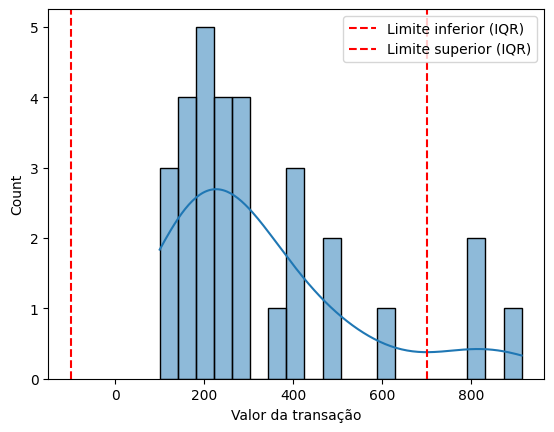

In [88]:
import seaborn as sns
import matplotlib.pyplot as plt

# Histograma com KDE
sns.histplot(data['Valor da transação'], bins=20, kde=True)

# Linhas dos limites IQR (exemplo usando sua função)
plt.axvline(limite_inferior, color='red', linestyle='--', label='Limite inferior (IQR)')
plt.axvline(limite_superior, color='red', linestyle='--', label='Limite superior (IQR)')

plt.legend()
plt.show()
